# CPU Baseline — Non-Local Means Denoising

Notebook này xây dựng và đánh giá phiên bản **CPU baseline** của thuật toán
**Non-Local Means (NLM)** dành cho ảnh grayscale.

## Mục tiêu

- Chuẩn bị ảnh sạch và ảnh có Gaussian noise.
- Chạy phiên bản `nlm_cpu_naive`.
- Đo CPU runtime.
- Đánh giá chất lượng khử nhiễu bằng PSNR và SSIM.
- Hiển thị ảnh trước và sau khi khử nhiễu.
- Tạo CPU reference để kiểm tra correctness cho các phiên bản GPU.

Phiên bản CPU này ưu tiên tính rõ ràng và correctness, chưa tập trung vào tối ưu hiệu năng.

## 1. Xác định project root

Notebook có thể được chạy từ thư mục `notebooks/`, trong khi source code nằm trong
thư mục `src/`.

Cell dưới đây:

1. tìm thư mục gốc của project;
2. kiểm tra sự tồn tại của `src`, `kernels` và `pyproject.toml`;
3. thêm project root vào `sys.path`;
4. cho phép notebook import các module từ `src.nlm`.

In [1]:
from pathlib import Path
import sys


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (
            (path / "src").exists()
            and (path / "kernels").exists()
            and (path / "pyproject.toml").exists()
        ):
            return path

    raise FileNotFoundError(
        "Cannot locate project root."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: E:\Lap trinh song song ud\gpu_dense_vector_retrieval


## 2. Import thư viện và các module NLM

Các thư viện được sử dụng gồm:

- `time`: đo CPU runtime;
- `matplotlib`: hiển thị ảnh;
- `pandas`: tạo bảng kết quả;
- `NLMConfig`: quản lý cấu hình thí nghiệm;
- `nlm_cpu_naive`: CPU reference implementation;
- `image_utils`: tạo ảnh thử nghiệm và thêm Gaussian noise;
- `evaluate_denoising`: tính các quality metrics.

In [2]:
import time

import matplotlib.pyplot as plt
import pandas as pd

from src.nlm.config import NLMConfig
from src.nlm.cpu import nlm_cpu_naive
from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)
from src.nlm.metrics import evaluate_denoising

## 3. Cấu hình thí nghiệm

Thí nghiệm sử dụng các tham số:

- Kích thước ảnh: `64 × 64`.
- Gaussian noise sigma: `0.08`.
- Patch size: `3 × 3`.
- Search window: `7 × 7`.
- Filtering parameter `h`: `0.12`.
- Random seed: `42`.

Việc sử dụng cùng một `NLMConfig` giúp CPU và các phiên bản GPU chạy với cùng tham số,
từ đó bảo đảm tính công bằng khi so sánh correctness và runtime.

In [3]:
config = NLMConfig(
    image_size=64,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    random_seed=42,
)

config.validate()

print(config)

NLMConfig(image_size=64, noise_sigma=0.08, patch_size=3, search_window_size=7, h=0.12, random_seed=42, block_size_x=16, block_size_y=16)


## 4. Chuẩn bị dữ liệu thử nghiệm

Hai ảnh được tạo:

1. `clean_image`: ảnh grayscale sạch dùng làm ground truth;
2. `noisy_image`: ảnh sạch sau khi được thêm Gaussian noise.

Random seed được cố định để noise pattern không thay đổi giữa các lần chạy.
Nhờ đó CPU, GPU V1, GPU V2 và GPU V3 có thể được đánh giá trên cùng một input.

In [4]:
clean_image = create_camera_test_image(
    config.image_size
)

noisy_image = add_gaussian_noise(
    clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

## 5. Chạy CPU baseline

Phiên bản `nlm_cpu_naive` xử lý từng output pixel theo thứ tự tuần tự.

Với mỗi output pixel, CPU thực hiện:

1. lấy reference patch;
2. duyệt toàn bộ candidate patch trong search window;
3. tính mean squared patch distance;
4. chuyển distance thành similarity weight;
5. tính weighted average của các candidate center pixels;
6. ghi kết quả vào output image.

Runtime được đo bằng `time.perf_counter()`.

Đây là CPU baseline dùng để:

- làm reference về correctness;
- tính speedup cho các phiên bản GPU;
- kiểm tra GPU output bằng pixel-wise comparison.

In [5]:
start = time.perf_counter()

denoised_cpu = nlm_cpu_naive(
    noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
)

cpu_runtime_seconds = (
    time.perf_counter()
    - start
)

cpu_metrics = evaluate_denoising(
    clean_image,
    noisy_image,
    denoised_cpu,
)

print(
    f"CPU runtime: "
    f"{cpu_runtime_seconds:.6f} giây"
)

metrics_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU baseline",
            "Runtime (s)": cpu_runtime_seconds,
            **cpu_metrics,
        }
    ]
)

display(metrics_table)

CPU runtime: 1.820475 giây


,Implementation,Runtime (s),noisy_psnr,denoised_psnr,denoised_ssim,psnr_improvement
0,CPU baseline,1.820475,22.218338,29.53202,0.838319,7.313682


### Ý nghĩa các quality metrics

- **PSNR**: đo mức độ gần nhau giữa ảnh kết quả và ảnh sạch. PSNR càng cao thì chất lượng tái tạo thường càng tốt.
- **SSIM**: đánh giá mức độ bảo toàn cấu trúc của ảnh. Giá trị càng gần `1` thì hai ảnh càng giống nhau về cấu trúc.
- **Runtime**: tổng thời gian CPU cần để hoàn thành NLM cho toàn bộ ảnh.

CPU runtime ở đây được sử dụng làm mốc `1×` khi tính speedup của GPU V1, GPU V2 và GPU V3.

## 6. Hiển thị kết quả

Ba ảnh được hiển thị cạnh nhau:

- **Clean**: ảnh ground truth;
- **Noisy**: ảnh sau khi thêm Gaussian noise;
- **CPU NLM**: kết quả sau khi khử nhiễu bằng CPU baseline.

Mục tiêu của bước này là kiểm tra trực quan khả năng giảm noise và mức độ bảo toàn
các cấu trúc chính trong ảnh.

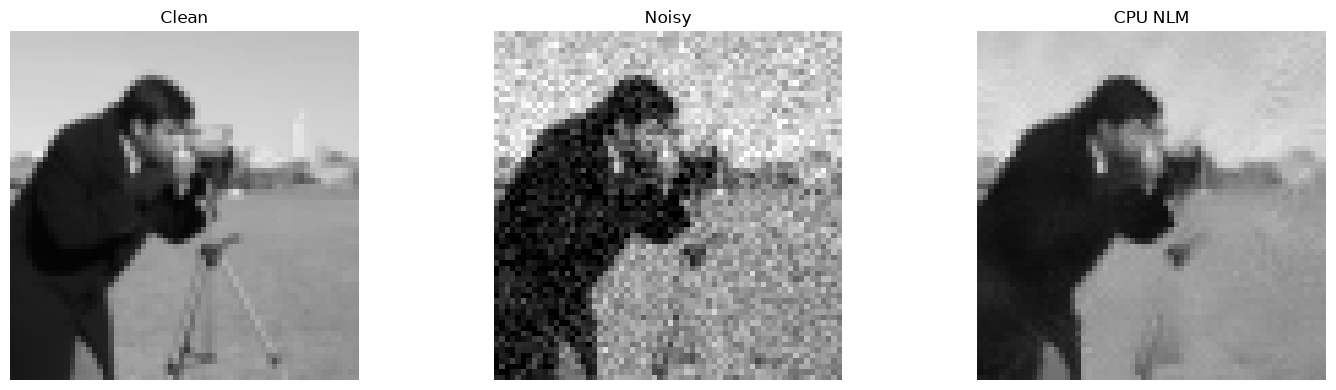

In [6]:
plt.figure(figsize=(15, 4))

images = [
    ("Clean", clean_image),
    ("Noisy", noisy_image),
    ("CPU NLM", denoised_cpu),
]

for index, (title, image) in enumerate(
    images,
    start=1,
):
    plt.subplot(1, 3, index)
    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. So sánh CPU NLM với các bộ lọc khử nhiễu cơ bản

Để đánh giá rõ hơn lợi ích của Non-Local Means, phần này so sánh
CPU NLM với hai phương pháp khử nhiễu cục bộ phổ biến:

- **Mean filter**: thay mỗi pixel bằng giá trị trung bình của các pixel lân cận;
- **Gaussian filter**: tính trung bình có trọng số, trong đó các pixel gần tâm
  có trọng số lớn hơn;
- **Non-Local Means**: tìm và kết hợp các patch có cấu trúc tương tự trong
  search window.

Tất cả phương pháp sử dụng cùng một ảnh nhiễu đầu vào. Kết quả được đánh giá
bằng ba tiêu chí:

- **PSNR**: đo sai số giữa ảnh khử nhiễu và ảnh sạch; giá trị cao hơn thường tốt hơn;
- **SSIM**: đo khả năng bảo toàn cấu trúc; giá trị càng gần `1` càng tốt;
- **Runtime**: thời gian thực thi của từng phương pháp.


In [7]:
import cv2
import numpy as np

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

Hàm benchmark và các bộ lọc

In [8]:
def benchmark_denoiser(
    denoise_function,
    noisy_input: np.ndarray,
    number_of_runs: int = 3,
) -> tuple[np.ndarray, float]:
    """
    Chạy một phương pháp khử nhiễu nhiều lần và trả về:

    1. output của lần chạy cuối;
    2. median runtime của các lần chạy.

    Median được sử dụng để giảm ảnh hưởng của các dao động runtime ngẫu nhiên.
    """

    runtimes = []
    denoised_output = None

    for _ in range(number_of_runs):
        start = time.perf_counter()

        denoised_output = denoise_function(
            noisy_input
        )

        runtime = (
            time.perf_counter()
            - start
        )

        runtimes.append(runtime)

    denoised_output = np.asarray(
        denoised_output,
        dtype=np.float32,
    )

    return (
        denoised_output,
        float(np.median(runtimes)),
    )


def mean_filter(
    image: np.ndarray,
) -> np.ndarray:
    """
    Mean filter 3 × 3.

    Mỗi output pixel là giá trị trung bình của
    vùng lân cận 3 × 3.
    """

    return cv2.blur(
        image,
        ksize=(3, 3),
        borderType=cv2.BORDER_REFLECT,
    ).astype(np.float32)


def gaussian_filter(
    image: np.ndarray,
) -> np.ndarray:
    """
    Gaussian filter 3 × 3 với sigma = 1.0.

    Các pixel gần tâm kernel có trọng số lớn hơn
    các pixel ở xa tâm.
    """

    return cv2.GaussianBlur(
        image,
        ksize=(3, 3),
        sigmaX=1.0,
        sigmaY=1.0,
        borderType=cv2.BORDER_REFLECT,
    ).astype(np.float32)


def cpu_nlm_filter(
    image: np.ndarray,
) -> np.ndarray:
    """
    Wrapper gọi CPU NLM bằng đúng cấu hình
    đã sử dụng trong CPU baseline.
    """

    return nlm_cpu_naive(
        image,
        patch_size=config.patch_size,
        search_window_size=(
            config.search_window_size
        ),
        h=config.h,
    )

Chạy benchmark

In [9]:
NUMBER_OF_COMPARISON_RUNS = 3

mean_output, mean_runtime = benchmark_denoiser(
    mean_filter,
    noisy_image,
    number_of_runs=NUMBER_OF_COMPARISON_RUNS,
)

gaussian_output, gaussian_runtime = benchmark_denoiser(
    gaussian_filter,
    noisy_image,
    number_of_runs=NUMBER_OF_COMPARISON_RUNS,
)

nlm_output, nlm_runtime = benchmark_denoiser(
    cpu_nlm_filter,
    noisy_image,
    number_of_runs=NUMBER_OF_COMPARISON_RUNS,
)

Tính PSNR và SSIM

In [10]:
def calculate_quality_metrics(
    clean_reference: np.ndarray,
    processed_image: np.ndarray,
) -> dict[str, float]:
    """
    Tính PSNR và SSIM giữa ảnh kết quả
    và ảnh sạch ground truth.
    """

    processed_image = np.clip(
        processed_image,
        0.0,
        1.0,
    ).astype(np.float32)

    psnr_value = peak_signal_noise_ratio(
        clean_reference,
        processed_image,
        data_range=1.0,
    )

    ssim_value = structural_similarity(
        clean_reference,
        processed_image,
        data_range=1.0,
    )

    return {
        "PSNR (dB)": float(psnr_value),
        "SSIM": float(ssim_value),
    }


comparison_results = [
    {
        "Method": "Noisy image",
        "Runtime (s)": np.nan,
        **calculate_quality_metrics(
            clean_image,
            noisy_image,
        ),
    },
    {
        "Method": "Mean filter",
        "Runtime (s)": mean_runtime,
        **calculate_quality_metrics(
            clean_image,
            mean_output,
        ),
    },
    {
        "Method": "Gaussian filter",
        "Runtime (s)": gaussian_runtime,
        **calculate_quality_metrics(
            clean_image,
            gaussian_output,
        ),
    },
    {
        "Method": "CPU NLM",
        "Runtime (s)": nlm_runtime,
        **calculate_quality_metrics(
            clean_image,
            nlm_output,
        ),
    },
]

comparison_table = pd.DataFrame(
    comparison_results
)

display(
    comparison_table.style.format(
        {
            "Runtime (s)": "{:.6f}",
            "PSNR (dB)": "{:.4f}",
            "SSIM": "{:.4f}",
        },
        na_rep="—",
    )
)

,Method,Runtime (s),PSNR (dB),SSIM
0,Noisy image,—,22.2183,0.4938
1,Mean filter,0.000024,26.4665,0.7293
2,Gaussian filter,0.000059,27.0886,0.7319
3,CPU NLM,1.833152,29.5320,0.8383


Hiển thị kết quả trực quan

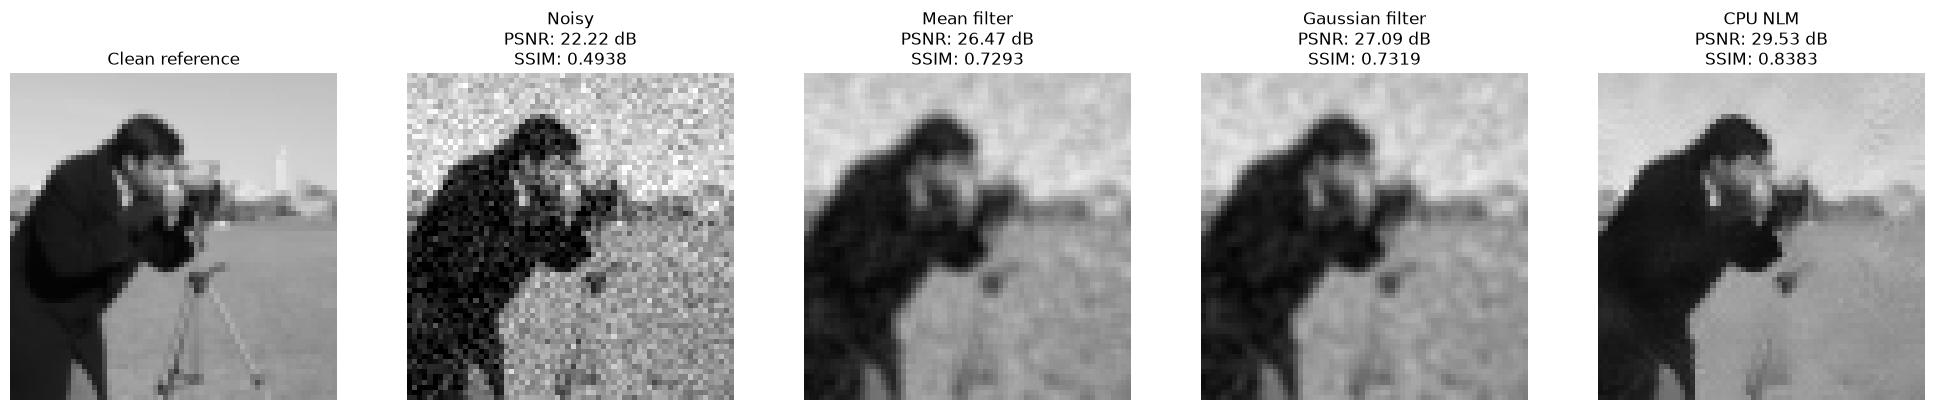

In [11]:
comparison_images = [
    (
        "Clean reference",
        clean_image,
    ),
    (
        "Noisy",
        noisy_image,
    ),
    (
        "Mean filter",
        mean_output,
    ),
    (
        "Gaussian filter",
        gaussian_output,
    ),
    (
        "CPU NLM",
        nlm_output,
    ),
]

comparison_metrics_lookup = {
    row["Method"]: row
    for row in comparison_results
}

figure, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4),
)

for axis, (title, image) in zip(
    axes,
    comparison_images,
):
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    if title == "Clean reference":
        display_title = title
    else:
        method_name = (
            "Noisy image"
            if title == "Noisy"
            else title
        )

        metrics = comparison_metrics_lookup[
            method_name
        ]

        display_title = (
            f"{title}\n"
            f"PSNR: {metrics['PSNR (dB)']:.2f} dB\n"
            f"SSIM: {metrics['SSIM']:.4f}"
        )

    axis.set_title(display_title)
    axis.axis("off")

plt.tight_layout()
plt.show()

Biểu đồ chất lượng và runtime

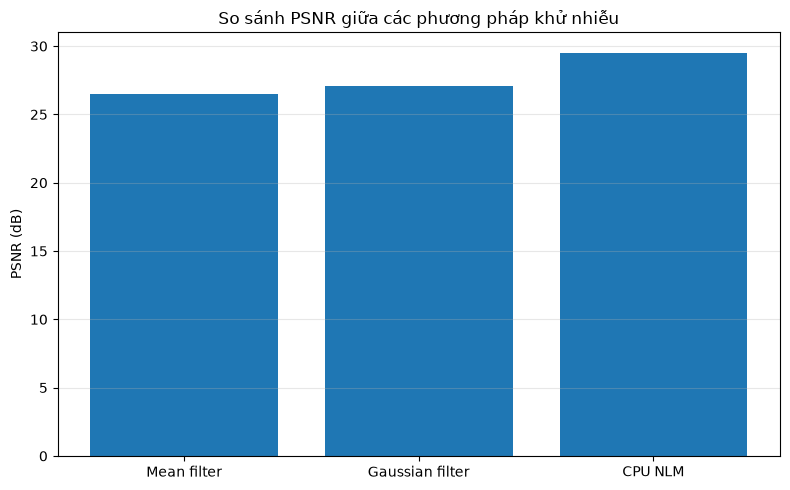

In [12]:
denoising_methods = comparison_table[
    comparison_table["Method"] != "Noisy image"
].copy()

plt.figure(figsize=(8, 5))

plt.bar(
    denoising_methods["Method"],
    denoising_methods["PSNR (dB)"],
)

plt.ylabel("PSNR (dB)")
plt.title(
    "So sánh PSNR giữa các phương pháp khử nhiễu"
)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

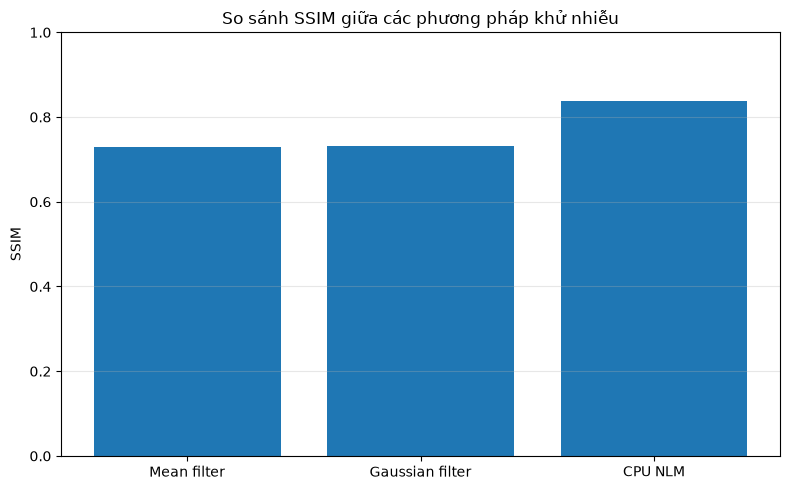

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    denoising_methods["Method"],
    denoising_methods["SSIM"],
)

plt.ylabel("SSIM")
plt.ylim(0.0, 1.0)
plt.title(
    "So sánh SSIM giữa các phương pháp khử nhiễu"
)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

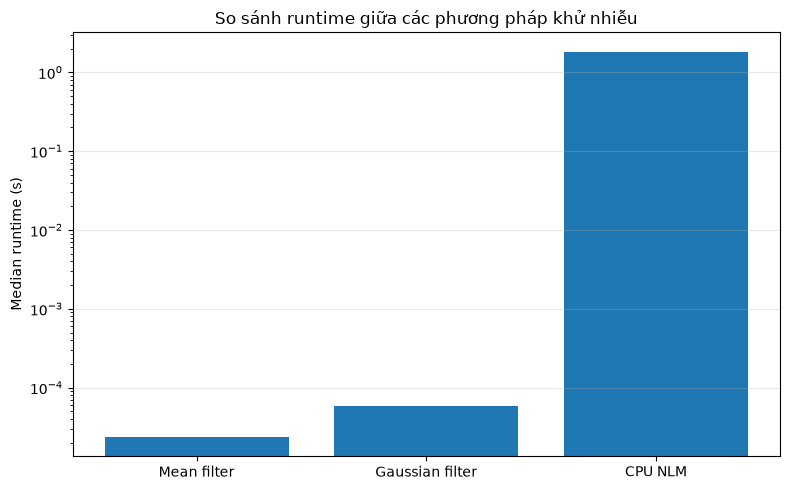

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    denoising_methods["Method"],
    denoising_methods["Runtime (s)"],
)

plt.ylabel("Median runtime (s)")
plt.yscale("log")
plt.title(
    "So sánh runtime giữa các phương pháp khử nhiễu"
)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

Mean filter và Gaussian filter thực hiện phép lọc cục bộ nên có runtime rất thấp.
Tuy nhiên, các phương pháp này có thể làm mờ edge và texture do kết hợp các pixel
chủ yếu dựa trên vị trí không gian.

Non-Local Means sử dụng độ tương đồng giữa các patch để xác định trọng số.
Cách tiếp cận này có khả năng bảo toàn cấu trúc tốt hơn trong một số trường hợp,
nhưng yêu cầu số lượng phép tính lớn hơn đáng kể.

## 8. Phân tích khả năng mở rộng của CPU NLM theo kích thước ảnh

Phần này khảo sát runtime của CPU NLM khi kích thước ảnh tăng, trong khi các
tham số NLM khác được giữ cố định.

Với ảnh có kích thước $H \times W$, patch size $P \times P$ và search window
$S \times S$, chi phí tính toán gần đúng của naive NLM là:

$$
O(HW \cdot S^2 \cdot P^2)
$$

Trong thí nghiệm này, `patch_size` và `search_window_size` được giữ cố định.
Vì vậy, workload dự kiến tăng gần tỷ lệ thuận với số lượng output pixel $H \times W$.

Khi chiều rộng và chiều cao cùng tăng gấp đôi:

- số pixel tăng khoảng $4\times$;
- số lần so sánh patch cũng tăng khoảng $4\times$;
- runtime CPU được kỳ vọng tăng đáng kể.

Các kích thước mặc định được khảo sát là:

- $64 \times 64$;
- $128 \times 128$;
- $256 \times 256$.

In [15]:
SCALABILITY_IMAGE_SIZES = [
    64,
    128,
    256,
]

RUN_512_BENCHMARK = False

if RUN_512_BENCHMARK:
    SCALABILITY_IMAGE_SIZES.append(512)

SCALABILITY_REPEATS = 3

print(
    "Các kích thước sẽ benchmark:",
    SCALABILITY_IMAGE_SIZES,
)

Các kích thước sẽ benchmark: [64, 128, 256]


Hàm benchmark theo kích thước

In [16]:
def benchmark_nlm_scalability(
    image_sizes: list[int],
    number_of_runs: int = 3,
) -> pd.DataFrame:
    """
    Benchmark CPU NLM trên nhiều kích thước ảnh.

    Các tham số noise, patch size, search window và h
    được giữ cố định để chỉ quan sát tác động của
    số lượng pixel.
    """

    benchmark_rows = []

    for image_size in image_sizes:
        print(
            f"Đang benchmark ảnh "
            f"{image_size} × {image_size}..."
        )

        clean_test_image = (
            create_camera_test_image(
                image_size
            )
        )

        noisy_test_image = add_gaussian_noise(
            clean_test_image,
            sigma=config.noise_sigma,
            seed=config.random_seed,
        )

        runtimes = []
        denoised_test_image = None

        for run_index in range(
            number_of_runs
        ):
            start = time.perf_counter()

            denoised_test_image = nlm_cpu_naive(
                noisy_test_image,
                patch_size=config.patch_size,
                search_window_size=(
                    config.search_window_size
                ),
                h=config.h,
            )

            elapsed_time = (
                time.perf_counter()
                - start
            )

            runtimes.append(
                elapsed_time
            )

            print(
                f"  Lần {run_index + 1}: "
                f"{elapsed_time:.6f} giây"
            )

        median_runtime = float(
            np.median(runtimes)
        )

        number_of_pixels = (
            image_size
            * image_size
        )

        candidate_count_per_pixel = (
            config.search_window_size
            ** 2
        )

        patch_values_per_candidate = (
            config.patch_size
            ** 2
        )

        estimated_patch_operations = (
            number_of_pixels
            * candidate_count_per_pixel
            * patch_values_per_candidate
        )

        quality_metrics = (
            calculate_quality_metrics(
                clean_test_image,
                denoised_test_image,
            )
        )

        benchmark_rows.append(
            {
                "Image size": (
                    f"{image_size} × "
                    f"{image_size}"
                ),
                "Width": image_size,
                "Height": image_size,
                "Number of pixels": (
                    number_of_pixels
                ),
                "Estimated patch operations": (
                    estimated_patch_operations
                ),
                "Median runtime (s)": (
                    median_runtime
                ),
                "PSNR (dB)": (
                    quality_metrics["PSNR (dB)"]
                ),
                "SSIM": (
                    quality_metrics["SSIM"]
                ),
            }
        )

    result_table = pd.DataFrame(
        benchmark_rows
    )

    baseline_pixels = result_table.loc[
        0,
        "Number of pixels",
    ]

    baseline_runtime = result_table.loc[
        0,
        "Median runtime (s)",
    ]

    result_table[
        "Pixel growth ratio"
    ] = (
        result_table["Number of pixels"]
        / baseline_pixels
    )

    result_table[
        "Runtime growth ratio"
    ] = (
        result_table["Median runtime (s)"]
        / baseline_runtime
    )

    result_table[
        "Time per pixel (µs)"
    ] = (
        result_table["Median runtime (s)"]
        / result_table["Number of pixels"]
        * 1_000_000.0
    )

    return result_table

Chạy scalability benchmark

In [17]:
scalability_table = benchmark_nlm_scalability(
    SCALABILITY_IMAGE_SIZES,
    number_of_runs=SCALABILITY_REPEATS,
)

display(
    scalability_table.style.format(
        {
            "Number of pixels": "{:,.0f}",
            "Estimated patch operations": (
                "{:,.0f}"
            ),
            "Median runtime (s)": "{:.6f}",
            "PSNR (dB)": "{:.4f}",
            "SSIM": "{:.4f}",
            "Pixel growth ratio": "{:.2f}×",
            "Runtime growth ratio": "{:.2f}×",
            "Time per pixel (µs)": "{:.2f}",
        }
    )
)

Đang benchmark ảnh 64 × 64...
  Lần 1: 1.873128 giây
  Lần 2: 1.811247 giây
  Lần 3: 1.813447 giây
Đang benchmark ảnh 128 × 128...
  Lần 1: 7.275012 giây
  Lần 2: 7.247314 giây
  Lần 3: 7.235976 giây
Đang benchmark ảnh 256 × 256...
  Lần 1: 29.101539 giây
  Lần 2: 29.291723 giây
  Lần 3: 29.174929 giây


,Image size,Width,Height,Number of pixels,Estimated patch operations,Median runtime (s),PSNR (dB),SSIM,Pixel growth ratio,Runtime growth ratio,Time per pixel (µs)
0,64 × 64,64,64,"4,096","1,806,336",1.813447,29.5320,0.8383,1.00×,1.00×,442.74
1,128 × 128,128,128,"16,384","7,225,344",7.247314,30.1526,0.8188,4.00×,4.00×,442.34
2,256 × 256,256,256,"65,536","28,901,376",29.174929,30.4435,0.7858,16.00×,16.09×,445.17


Biểu đồ runtime

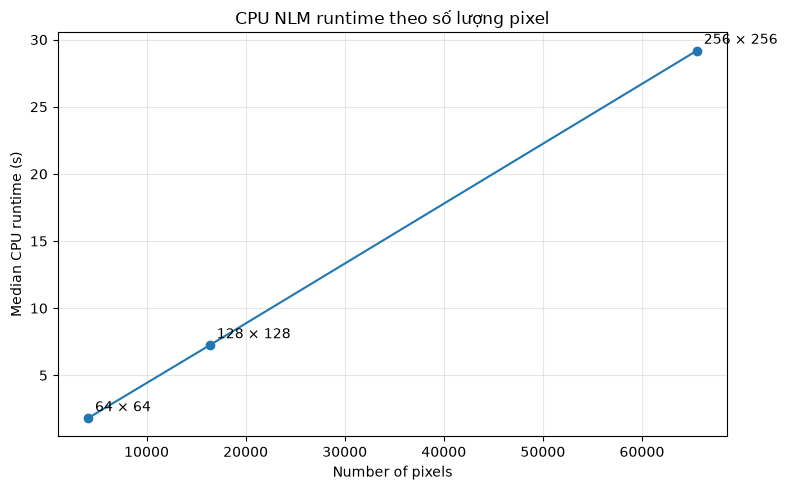

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    scalability_table[
        "Number of pixels"
    ],
    scalability_table[
        "Median runtime (s)"
    ],
    marker="o",
)

for _, row in scalability_table.iterrows():
    plt.annotate(
        row["Image size"],
        (
            row["Number of pixels"],
            row["Median runtime (s)"],
        ),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Number of pixels")
plt.ylabel("Median CPU runtime (s)")
plt.title(
    "CPU NLM runtime theo số lượng pixel"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

So sánh pixel growth và runtime growth

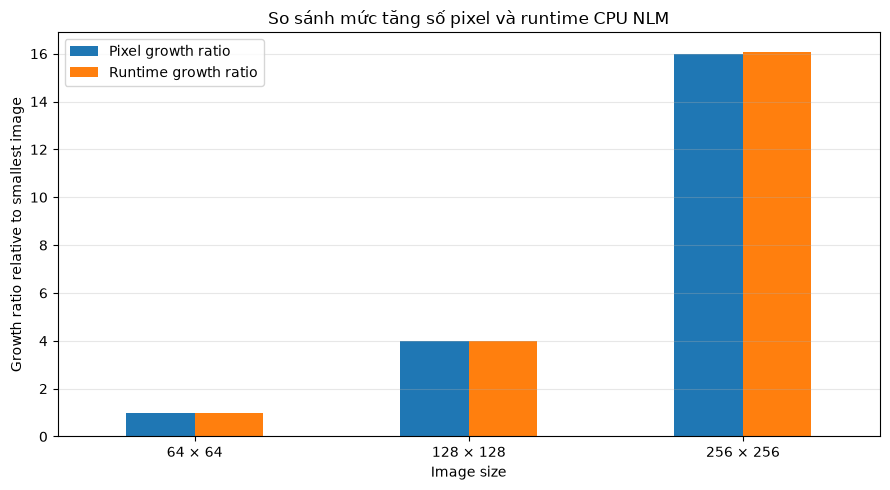

In [19]:
growth_comparison = scalability_table[
    [
        "Image size",
        "Pixel growth ratio",
        "Runtime growth ratio",
    ]
].set_index(
    "Image size"
)

growth_comparison.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.ylabel(
    "Growth ratio relative to smallest image"
)
plt.title(
    "So sánh mức tăng số pixel và runtime CPU NLM"
)
plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()